In [49]:
import pandas as pd

df = pd.read_csv('weather_data_hanoi.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24275 entries, 0 to 24274
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   aqi              24275 non-null  int64  
 1   co               24275 non-null  float64
 2   datetime         24275 non-null  object 
 3   no2              24275 non-null  float64
 4   o3               24275 non-null  float64
 5   pm10             24275 non-null  float64
 6   pm25             24275 non-null  float64
 7   so2              24275 non-null  float64
 8   timestamp_local  24275 non-null  object 
 9   timestamp_utc    24275 non-null  object 
 10  ts               24275 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 2.0+ MB
None
   aqi     co       datetime    no2    o3   pm10   pm25    so2  \
0  160  340.0  2023-01-30:17   47.3  46.0   78.8   63.0  110.0   
1  173  357.9  2023-01-30:16   50.7  53.0   91.3   73.0  121.0   
2  195  375.8  2023-01-30:15

In [50]:
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
print("Các cột không phải số:", non_numeric_columns.tolist())

Các cột không phải số: ['datetime', 'timestamp_local', 'timestamp_utc']


In [51]:
df['datetime'] = pd.to_datetime(df['datetime'], format='%Y-%m-%d:%H')
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday

#Loại bỏ các cột không cần thiết
df = df.drop(columns=['timestamp_utc', 'ts', 'datetime', 'timestamp_local'])
print(df.head())

   aqi     co    no2    o3   pm10   pm25    so2  year  month  day  hour  \
0  160  340.0   47.3  46.0   78.8   63.0  110.0  2023      1   30    17   
1  173  357.9   50.7  53.0   91.3   73.0  121.0  2023      1   30    16   
2  195  375.8   54.0  60.0  111.3   89.0  132.0  2023      1   30    15   
3  211  454.8   77.3  57.7  126.3  101.0  135.3  2023      1   30    14   
4  258  533.8  100.7  55.3  171.3  137.0  138.7  2023      1   30    13   

   weekday  
0        0  
1        0  
2        0  
3        0  
4        0  


In [52]:
num_features = df.shape[1]  # Số cột (đặc trưng)
num_samples = df.shape[0]   # Số dòng (mẫu)

print(f"Số lượng đặc trưng: {num_features}")
print(f"Số lượng mẫu: {num_samples}")
print(f"Tỷ lệ đặc trưng/mẫu: {num_features / num_samples:.2f}")

Số lượng đặc trưng: 12
Số lượng mẫu: 24275
Tỷ lệ đặc trưng/mẫu: 0.00


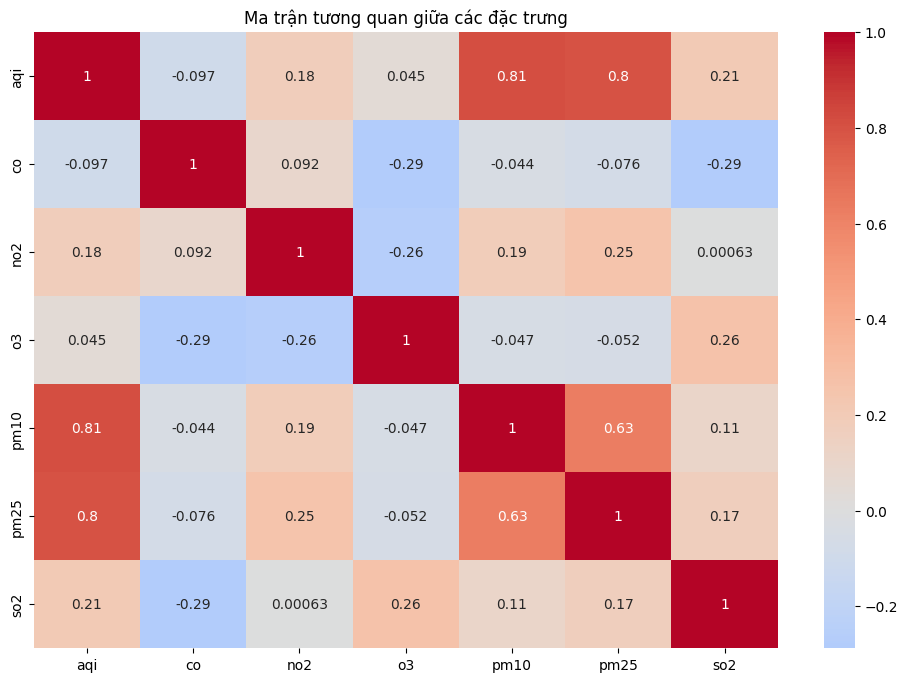

Các cặp đặc trưng có tương quan cao:
aqi   pm10    0.811848
pm10  aqi     0.811848
dtype: float64


In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

# Hiển thị ma trận tương quan
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()

# Kiểm tra các cặp đặc trưng có tương quan cao
high_corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs < 1]  # Loại bỏ giá trị tương quan = 1 (chính nó)
print("Các cặp đặc trưng có tương quan cao:")
print(high_corr_pairs[high_corr_pairs > 0.8])  # Ngưỡng tương quan cao (> 0.8)

In [54]:
df.drop(columns=['aqi'], inplace=True)

In [55]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['pm25']) # Đặc trưng
y = df['pm25']  # Target

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

print("Kích thước tập huấn luyện:", X_train.shape, y_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape, y_test.shape)


Kích thước tập huấn luyện: (19420, 10) (19420,)
Kích thước tập kiểm tra: (4855, 10) (4855,)


In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
print("="*70)
print("CHUẨN BỊ DỮ LIỆU: GỐC VÀ ĐÃ CHUẨN HÓA")
print("="*70)

# Dataset 1: Dữ liệu GỐC (không chuẩn hóa)
X_train_original = X_train.copy()
X_test_original = X_test.copy()

print("Dataset 1: Dữ liệu GỐC (không chuẩn hóa)")
print(f"   - X_train shape: {X_train_original.shape}")
print(f"   - X_test shape: {X_test_original.shape}")

# Dataset 2: Dữ liệu ĐÃ CHUẨN HÓA
print("\nDataset 2: Dữ liệu ĐÃ CHUẨN HÓA (StandardScaler)")
print(f"   - X_train shape: {X_train_scaled.shape}")
print(f"   - X_test shape: {X_test_scaled.shape}")

print("\nThống kê dữ liệu GỐC (5 features đầu tiên):")
print(X_train_original.iloc[:3, :5])

print("\nThống kê dữ liệu ĐÃ CHUẨN HÓA (5 features đầu tiên):")
print(pd.DataFrame(X_train_scaled[:3, :5], columns=X_train.columns[:5]))

print("="*70)

CHUẨN BỊ DỮ LIỆU: GỐC VÀ ĐÃ CHUẨN HÓA
Dataset 1: Dữ liệu GỐC (không chuẩn hóa)
   - X_train shape: (19420, 10)
   - X_test shape: (4855, 10)

Dataset 2: Dữ liệu ĐÃ CHUẨN HÓA (StandardScaler)
   - X_train shape: (19420, 10)
   - X_test shape: (4855, 10)

Thống kê dữ liệu GỐC (5 features đầu tiên):
          co   no2     o3  pm10    so2
17619  215.0  18.0   96.0  67.7  109.3
6759   228.2  22.0  100.0  96.3  135.3
6252   183.1  19.3   55.7  25.0  113.7

Thống kê dữ liệu ĐÃ CHUẨN HÓA (5 features đầu tiên):
         co       no2        o3      pm10       so2
0 -0.428706 -0.400358  0.978853 -0.029504  0.742104
1 -0.414501 -0.284755  1.070174  0.348834  1.156207
2 -0.463035 -0.362787  0.058789 -0.594364  0.812183


In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import time

print("\n" + "="*70)
print("PHẦN 1: HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU GỐC (KHÔNG CHUẨN HÓA)")
print("="*70 + "\n")

# Khởi tạo các mô hình
models_original = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Dictionary lưu kết quả
results_original = {}

# Huấn luyện và đánh giá từng mô hình
for name, model in models_original.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Huấn luyện
    model.fit(X_train_original, y_train)
    
    # Dự đoán
    y_pred_train = model.predict(X_train_original)
    y_pred_test = model.predict(X_test_original)
    
    # Tính toán metrics
    train_mse = mean_squared_error(y_train, y_pred_train)
    train_rmse = train_mse ** 0.5
    train_r2 = r2_score(y_train, y_pred_train)
    
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = test_mse ** 0.5
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    elapsed_time = time.time() - start_time
    
    # Lưu kết quả
    results_original[name] = {
        "Train MSE": train_mse,
        "Train RMSE": train_rmse,
        "Train R²": train_r2,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "Test R²": test_r2,
        "Training Time": elapsed_time,
        "Model": model
    }
    
    print(f"   {name}: R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}, Time = {elapsed_time:.2f}s\n")

# Hiển thị kết quả tổng hợp
print("="*70)
print("KẾT QUẢ TRÊN DỮ LIỆU GỐC")
print("="*70)

results_df_original = pd.DataFrame({
    'Model': list(results_original.keys()),
    'Train R²': [results_original[m]['Train R²'] for m in results_original.keys()],
    'Test R²': [results_original[m]['Test R²'] for m in results_original.keys()],
    'Test RMSE': [results_original[m]['Test RMSE'] for m in results_original.keys()],
    'Test MAE': [results_original[m]['Test MAE'] for m in results_original.keys()],
    'Time (s)': [results_original[m]['Training Time'] for m in results_original.keys()]
})

results_df_original = results_df_original.sort_values('Test R²', ascending=False)
print(results_df_original.to_string(index=False))
print("="*70)


PHẦN 1: HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU GỐC (KHÔNG CHUẨN HÓA)

Training Linear Regression...
   Linear Regression: R² = 0.3885, RMSE = 30.8264, Time = 0.01s

Training Random Forest...
   Random Forest: R² = 0.9356, RMSE = 10.0031, Time = 2.22s

Training XGBoost...
   XGBoost: R² = 0.9416, RMSE = 9.5236, Time = 0.18s

KẾT QUẢ TRÊN DỮ LIỆU GỐC
            Model  Train R²  Test R²  Test RMSE  Test MAE  Time (s)
          XGBoost  0.990430 0.941631   9.523609  4.264054  0.176869
    Random Forest  0.993332 0.935606  10.003085  4.176660  2.217753
Linear Regression  0.437825 0.388465  30.826377 17.210365  0.014961
   Random Forest: R² = 0.9356, RMSE = 10.0031, Time = 2.22s

Training XGBoost...
   XGBoost: R² = 0.9416, RMSE = 9.5236, Time = 0.18s

KẾT QUẢ TRÊN DỮ LIỆU GỐC
            Model  Train R²  Test R²  Test RMSE  Test MAE  Time (s)
          XGBoost  0.990430 0.941631   9.523609  4.264054  0.176869
    Random Forest  0.993332 0.935606  10.003085  4.176660  2.217753
Linear Regression  

In [59]:
print("\n" + "="*70)
print("PHẦN 2: HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA")
print("="*70 + "\n")

# Khởi tạo các mô hình
models_scaled = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Dictionary lưu kết quả
results_scaled = {}

# Huấn luyện và đánh giá từng mô hình
for name, model in models_scaled.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Huấn luyện
    model.fit(X_train_scaled, y_train)
    
    # Dự đoán
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Tính toán metrics
    train_mse = mean_squared_error(y_train, y_pred_train)
    train_rmse = train_mse ** 0.5
    train_r2 = r2_score(y_train, y_pred_train)
    
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = test_mse ** 0.5
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    elapsed_time = time.time() - start_time
    
    # Lưu kết quả
    results_scaled[name] = {
        "Train MSE": train_mse,
        "Train RMSE": train_rmse,
        "Train R²": train_r2,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "Test R²": test_r2,
        "Training Time": elapsed_time,
        "Model": model
    }
    
    print(f"   {name}: R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}, Time = {elapsed_time:.2f}s\n")

# Hiển thị kết quả tổng hợp
print("="*70)
print("KẾT QUẢ TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA")
print("="*70)

results_df_scaled = pd.DataFrame({
    'Model': list(results_scaled.keys()),
    'Train R²': [results_scaled[m]['Train R²'] for m in results_scaled.keys()],
    'Test R²': [results_scaled[m]['Test R²'] for m in results_scaled.keys()],
    'Test RMSE': [results_scaled[m]['Test RMSE'] for m in results_scaled.keys()],
    'Test MAE': [results_scaled[m]['Test MAE'] for m in results_scaled.keys()],
    'Time (s)': [results_scaled[m]['Training Time'] for m in results_scaled.keys()]
})

results_df_scaled = results_df_scaled.sort_values('Test R²', ascending=False)
print(results_df_scaled.to_string(index=False))
print("="*70)


PHẦN 2: HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA

Training Linear Regression...
   Linear Regression: R² = 0.3885, RMSE = 30.8264, Time = 0.01s

Training Random Forest...
   Random Forest: R² = 0.9353, RMSE = 10.0239, Time = 2.47s

Training XGBoost...
   Random Forest: R² = 0.9353, RMSE = 10.0239, Time = 2.47s

Training XGBoost...
   XGBoost: R² = 0.9416, RMSE = 9.5236, Time = 0.29s

KẾT QUẢ TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA
            Model  Train R²  Test R²  Test RMSE  Test MAE  Time (s)
          XGBoost  0.990430 0.941631   9.523609  4.264054  0.291158
    Random Forest  0.993334 0.935338  10.023920  4.180554  2.473668
Linear Regression  0.437825 0.388465  30.826377 17.210365  0.010127
   XGBoost: R² = 0.9416, RMSE = 9.5236, Time = 0.29s

KẾT QUẢ TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA
            Model  Train R²  Test R²  Test RMSE  Test MAE  Time (s)
          XGBoost  0.990430 0.941631   9.523609  4.264054  0.291158
    Random Forest  0.993334 0.935338  10.023920  4.180554  2.473668
Linear Reg

In [60]:
print("\n" + "="*70)
print("SO SÁNH KẾT QUẢ: DỮ LIỆU GỐC vs DỮ LIỆU ĐÃ CHUẨN HÓA")
print("="*70 + "\n")

# Tạo DataFrame so sánh
comparison_data = []

for model_name in results_original.keys():
    original_r2 = results_original[model_name]['Test R²']
    original_rmse = results_original[model_name]['Test RMSE']
    original_mae = results_original[model_name]['Test MAE']
    
    scaled_r2 = results_scaled[model_name]['Test R²']
    scaled_rmse = results_scaled[model_name]['Test RMSE']
    scaled_mae = results_scaled[model_name]['Test MAE']
    
    # Tính % thay đổi
    r2_diff = ((scaled_r2 - original_r2) / abs(original_r2)) * 100 if original_r2 != 0 else 0
    rmse_diff = ((scaled_rmse - original_rmse) / original_rmse) * 100 if original_rmse != 0 else 0
    mae_diff = ((scaled_mae - original_mae) / original_mae) * 100 if original_mae != 0 else 0
    
    comparison_data.append({
        'Model': model_name,
        'Original R²': original_r2,
        'Scaled R²': scaled_r2,
        'R² Change (%)': r2_diff,
        'Original RMSE': original_rmse,
        'Scaled RMSE': scaled_rmse,
        'RMSE Change (%)': rmse_diff,
        'Original MAE': original_mae,
        'Scaled MAE': scaled_mae,
        'MAE Change (%)': mae_diff
    })

comparison_df = pd.DataFrame(comparison_data)

# Hiển thị R² comparison
print("SO SÁNH R² SCORE:")
print("-" * 70)
r2_comparison = comparison_df[['Model', 'Original R²', 'Scaled R²', 'R² Change (%)']].copy()
print(r2_comparison.to_string(index=False))

# Hiển thị RMSE comparison
print("\nSO SÁNH RMSE:")
print("-" * 70)
rmse_comparison = comparison_df[['Model', 'Original RMSE', 'Scaled RMSE', 'RMSE Change (%)']].copy()
print(rmse_comparison.to_string(index=False))

# Hiển thị MAE comparison
print("\nSO SÁNH MAE:")
print("-" * 70)
mae_comparison = comparison_df[['Model', 'Original MAE', 'Scaled MAE', 'MAE Change (%)']].copy()
print(mae_comparison.to_string(index=False))

# Tổng kết
print("\n" + "="*70)
print("KẾT LUẬN:")
print("="*70)

for model_name in results_original.keys():
    original_r2 = results_original[model_name]['Test R²']
    scaled_r2 = results_scaled[model_name]['Test R²']
    
    if scaled_r2 > original_r2:
        improvement = ((scaled_r2 - original_r2) / abs(original_r2)) * 100
        print(f"{model_name}: Chuẩn hóa CẢI THIỆN hiệu suất {improvement:+.2f}%")
    elif scaled_r2 < original_r2:
        degradation = ((scaled_r2 - original_r2) / abs(original_r2)) * 100
        print(f"{model_name}: Chuẩn hóa GIẢM hiệu suất {degradation:.2f}%")
    else:
        print(f"{model_name}: Chuẩn hóa KHÔNG ẢNH HƯỞNG")

print("="*70)


SO SÁNH KẾT QUẢ: DỮ LIỆU GỐC vs DỮ LIỆU ĐÃ CHUẨN HÓA

SO SÁNH R² SCORE:
----------------------------------------------------------------------
            Model  Original R²  Scaled R²  R² Change (%)
Linear Regression     0.388465   0.388465       0.000000
    Random Forest     0.935606   0.935338      -0.028701
          XGBoost     0.941631   0.941631       0.000000

SO SÁNH RMSE:
----------------------------------------------------------------------
            Model  Original RMSE  Scaled RMSE  RMSE Change (%)
Linear Regression      30.826377    30.826377         0.000000
    Random Forest      10.003085    10.023920         0.208288
          XGBoost       9.523609     9.523609         0.000000

SO SÁNH MAE:
----------------------------------------------------------------------
            Model  Original MAE  Scaled MAE  MAE Change (%)
Linear Regression     17.210365   17.210365   -1.651430e-13
    Random Forest      4.176660    4.180554    9.322957e-02
          XGBoost      4.


TRỰC QUAN HÓA KẾT QUẢ SO SÁNH



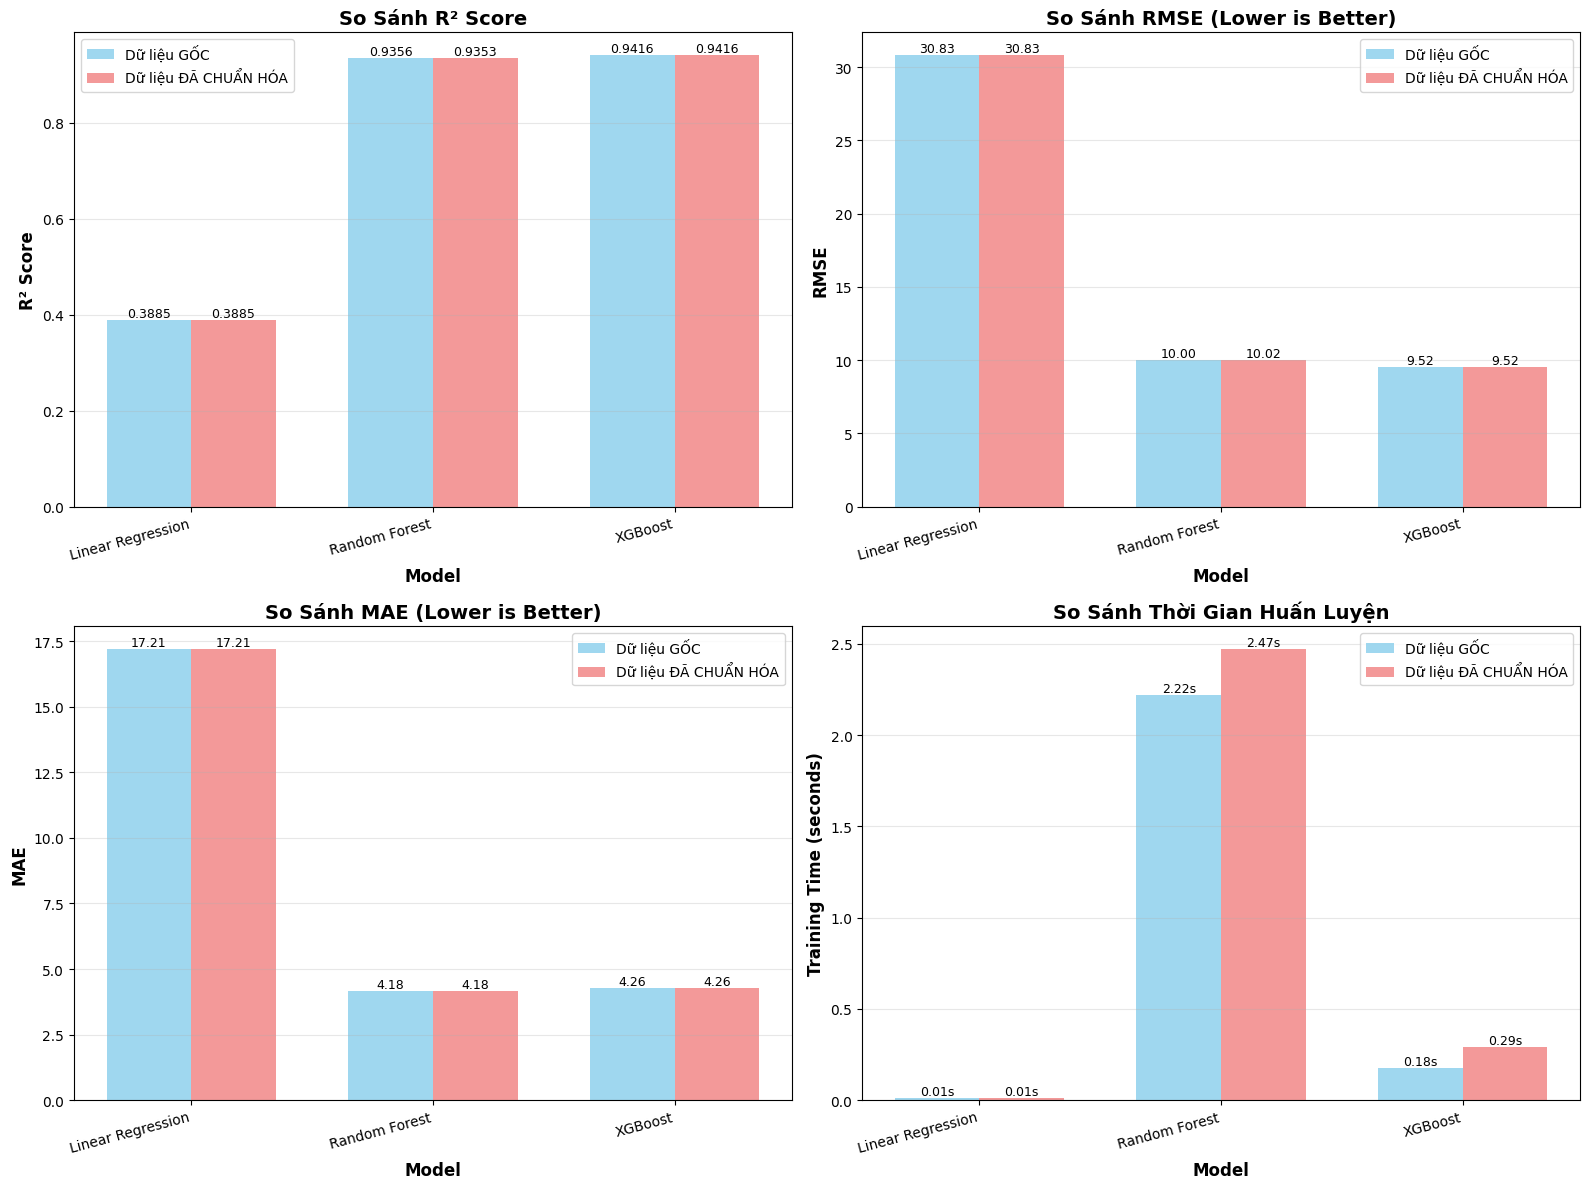

In [61]:
import matplotlib.pyplot as plt
import numpy as np

print("\nTRỰC QUAN HÓA KẾT QUẢ SO SÁNH\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. So sánh R² Score
ax1 = axes[0, 0]
models = list(results_original.keys())
x = np.arange(len(models))
width = 0.35

original_r2 = [results_original[m]['Test R²'] for m in models]
scaled_r2 = [results_scaled[m]['Test R²'] for m in models]

bars1 = ax1.bar(x - width/2, original_r2, width, label='Dữ liệu GỐC', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x + width/2, scaled_r2, width, label='Dữ liệu ĐÃ CHUẨN HÓA', alpha=0.8, color='lightcoral')

ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('So Sánh R² Score', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Thêm giá trị lên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# 2. So sánh RMSE
ax2 = axes[0, 1]
original_rmse = [results_original[m]['Test RMSE'] for m in models]
scaled_rmse = [results_scaled[m]['Test RMSE'] for m in models]

bars3 = ax2.bar(x - width/2, original_rmse, width, label='Dữ liệu GỐC', alpha=0.8, color='skyblue')
bars4 = ax2.bar(x + width/2, scaled_rmse, width, label='Dữ liệu ĐÃ CHUẨN HÓA', alpha=0.8, color='lightcoral')

ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax2.set_title('So Sánh RMSE (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Thêm giá trị lên các cột
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 3. So sánh MAE
ax3 = axes[1, 0]
original_mae = [results_original[m]['Test MAE'] for m in models]
scaled_mae = [results_scaled[m]['Test MAE'] for m in models]

bars5 = ax3.bar(x - width/2, original_mae, width, label='Dữ liệu GỐC', alpha=0.8, color='skyblue')
bars6 = ax3.bar(x + width/2, scaled_mae, width, label='Dữ liệu ĐÃ CHUẨN HÓA', alpha=0.8, color='lightcoral')

ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax3.set_title('So Sánh MAE (Lower is Better)', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Thêm giá trị lên các cột
for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 4. So sánh Training Time
ax4 = axes[1, 1]
original_time = [results_original[m]['Training Time'] for m in models]
scaled_time = [results_scaled[m]['Training Time'] for m in models]

bars7 = ax4.bar(x - width/2, original_time, width, label='Dữ liệu GỐC', alpha=0.8, color='skyblue')
bars8 = ax4.bar(x + width/2, scaled_time, width, label='Dữ liệu ĐÃ CHUẨN HÓA', alpha=0.8, color='lightcoral')

ax4.set_xlabel('Model', fontsize=12, fontweight='bold')
ax4.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax4.set_title('So Sánh Thời Gian Huấn Luyện', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models, rotation=15, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Thêm giá trị lên các cột
for bars in [bars7, bars8]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [63]:
print("="*70)
print("LƯU MÔ HÌNH VÀ SCALER")
print("="*70 + "\n")

import joblib

# Chọn mô hình tốt nhất từ dữ liệu gốc (Random Forest hoặc XGBoost từ results_original)
best_model_name_original = max(results_original, key=lambda x: results_original[x]['Test R²'])
best_model_original = results_original[best_model_name_original]['Model']

# Chọn mô hình tốt nhất từ dữ liệu đã chuẩn hóa
best_model_name_scaled = max(results_scaled, key=lambda x: results_scaled[x]['Test R²'])
best_model_scaled = results_scaled[best_model_name_scaled]['Model']

print(f" Mô hình được chọn từ dữ liệu gốc:")
print(f"   Mô hình: {best_model_name_original}")
print(f"   Test R²: {results_original[best_model_name_original]['Test R²']:.4f}")
print(f"   Test RMSE: {results_original[best_model_name_original]['Test RMSE']:.4f}")
print(f"   Test MAE: {results_original[best_model_name_original]['Test MAE']:.4f}")

print(f"\n Mô hình được chọn từ dữ liệu đã chuẩn hóa:")
print(f"   Mô hình: {best_model_name_scaled}")
print(f"   Test R²: {results_scaled[best_model_name_scaled]['Test R²']:.4f}")
print(f"   Test RMSE: {results_scaled[best_model_name_scaled]['Test RMSE']:.4f}")
print(f"   Test MAE: {results_scaled[best_model_name_scaled]['Test MAE']:.4f}")

# Lưu cả hai mô hình
joblib.dump(best_model_original, 'best_pm25_model_original.pkl')
joblib.dump(best_model_scaled, 'best_pm25_model_scaled.pkl')
# Lưu StandardScaler (QUAN TRỌNG cho prediction notebook)
joblib.dump(scaler, 'pm25_scaler.pkl')

print(f"\n ĐÃ LƯU CÁC FILE:")
print(f"    best_pm25_model_original.pkl")
print(f"    best_pm25_model_scaled.pkl")
print(f"    pm25_scaler.pkl (StandardScaler)")

print("\n" + "="*70)


LƯU MÔ HÌNH VÀ SCALER

 Mô hình được chọn từ dữ liệu gốc:
   Mô hình: XGBoost
   Test R²: 0.9416
   Test RMSE: 9.5236
   Test MAE: 4.2641

 Mô hình được chọn từ dữ liệu đã chuẩn hóa:
   Mô hình: XGBoost
   Test R²: 0.9416
   Test RMSE: 9.5236
   Test MAE: 4.2641

 ĐÃ LƯU CÁC FILE:
    best_pm25_model_original.pkl
    best_pm25_model_scaled.pkl
    pm25_scaler.pkl (StandardScaler)

